In [1]:
from core.sr_study_analysis import run_analysis, run_selected_configs, ExperimentSpec
from core.sr_sim import StudyType

## Scenarios and parameter grids

In [2]:
from core.dgp import IIDProcess, SkewTInnov, APDInnov
from core.sr_study_analysis import set_extra_dgps

DGP_EXAMPLES: dict[str, callable] = {
    "apd": (
        lambda: IIDProcess(APDInnov(alpha=0.7, lam=1.35))
    ),
}
set_extra_dgps(DGP_EXAMPLES)


In [3]:
# name : (dgp_names, model_short_names)
scenarios = {
    "base": (
        ["apd"],
        ["iid_nonnormal"],
    ),
}

parameters = {
    "sr":    [0.5, 1.0, 1.5],
    "T":     [100, 500, 2_000],
    "n_sim": [1_000, 3_000, 10_000],
}

## Experiment registry

Each entry is an `ExperimentSpec`.  
Set `study_type` to one of:
- `StudyType.TWO_SIDED_COVERAGE` / `ONE_SIDED_COVERAGE`  — size / coverage runs  
- `StudyType.TWO_SIDED_POWER`    / `ONE_SIDED_POWER`     — power runs (requires `null_sr`)

In [4]:
N_SIM  = 10_000
N_JOBS = 8

experiments = {
    "base": ExperimentSpec(
        scenario   = (["apd"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments=False,
        sr_default = 1.0,
        n_default  = N_SIM,
        n_jobs     = N_JOBS,
    ),
    "aux":ExperimentSpec(
        scenario     = (["apd"],["iid_nonnormal"]),
        param_name   = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type   = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments=False,
        sr_default = 1.0,
        n_default  = N_SIM,
        n_jobs     = N_JOBS,
        label_param  = "null_sr",          # ← new
        label_values = [0.0, 0.2, 1.0, 3.0],  # ← new
    )
}

---
## EXECUTION

In [5]:
# ── coverage / size runs ──────────────────────────────────────────────────────
run_selected_configs(
    experiments,
    selected_experiments=[
        #"base",
        "aux",
    ],
)


  Experiment: aux
  [1/20]  T=15  null_sr=0.0  (ONE_SIDED_COVERAGE)
  [2/20]  T=30  null_sr=0.0  (ONE_SIDED_COVERAGE)
  [3/20]  T=50  null_sr=0.0  (ONE_SIDED_COVERAGE)
  [4/20]  T=100  null_sr=0.0  (ONE_SIDED_COVERAGE)
  [5/20]  T=300  null_sr=0.0  (ONE_SIDED_COVERAGE)
  [6/20]  T=15  null_sr=0.2  (ONE_SIDED_COVERAGE)
  [7/20]  T=30  null_sr=0.2  (ONE_SIDED_COVERAGE)
  [8/20]  T=50  null_sr=0.2  (ONE_SIDED_COVERAGE)
  [9/20]  T=100  null_sr=0.2  (ONE_SIDED_COVERAGE)
  [10/20]  T=300  null_sr=0.2  (ONE_SIDED_COVERAGE)
  [11/20]  T=15  null_sr=1.0  (ONE_SIDED_COVERAGE)
  [12/20]  T=30  null_sr=1.0  (ONE_SIDED_COVERAGE)
  [13/20]  T=50  null_sr=1.0  (ONE_SIDED_COVERAGE)
  [14/20]  T=100  null_sr=1.0  (ONE_SIDED_COVERAGE)
  [15/20]  T=300  null_sr=1.0  (ONE_SIDED_COVERAGE)
  [16/20]  T=15  null_sr=3.0  (ONE_SIDED_COVERAGE)
  [17/20]  T=30  null_sr=3.0  (ONE_SIDED_COVERAGE)
  [18/20]  T=50  null_sr=3.0  (ONE_SIDED_COVERAGE)
  [19/20]  T=100  null_sr=3.0  (ONE_SIDED_COVERAGE)
  [20/20]  T=3

---
## VISUALIZATION — Coverage / Size

=== ONE_SIDED_COVERAGE — T sweep ===
 null_sr   T dgp_name    avar_model  nominal  coverage     bias     rmse
     0.0  15      apd iid_nonnormal     0.95    0.9302 0.034039 0.292933
     0.0  30      apd iid_nonnormal     0.95    0.9420 0.016872 0.195276
     0.0  50      apd iid_nonnormal     0.95    0.9442 0.011563 0.147078
     0.0 100      apd iid_nonnormal     0.95    0.9495 0.004618 0.101247
     0.0 300      apd iid_nonnormal     0.95    0.9539 0.001379 0.057597
     0.2  15      apd iid_nonnormal     0.95    0.9158 0.053463 0.330199
     0.2  30      apd iid_nonnormal     0.95    0.9300 0.026421 0.217808
     0.2  50      apd iid_nonnormal     0.95    0.9363 0.017213 0.164135
     0.2 100      apd iid_nonnormal     0.95    0.9460 0.007271 0.112975
     0.2 300      apd iid_nonnormal     0.95    0.9539 0.002269 0.064084
     1.0  15      apd iid_nonnormal     0.95    0.8719 0.131159 0.528413
     1.0  30      apd iid_nonnormal     0.95    0.9035 0.064621 0.339605
     1.0  50  

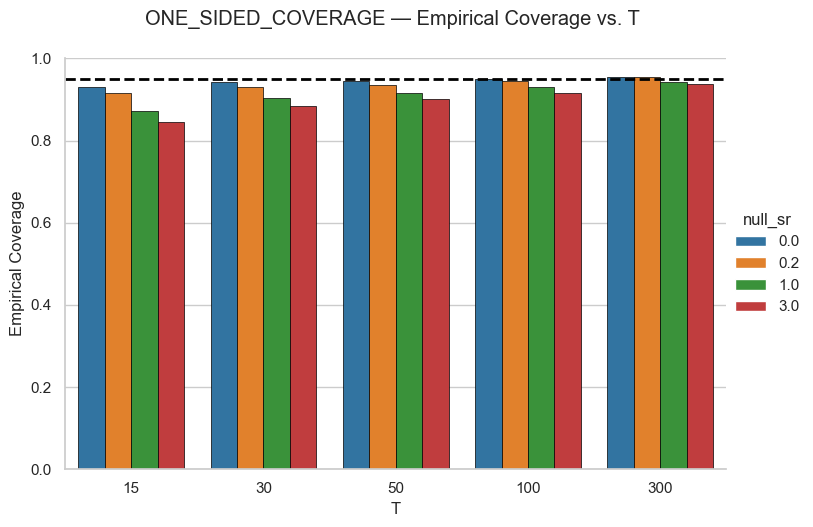

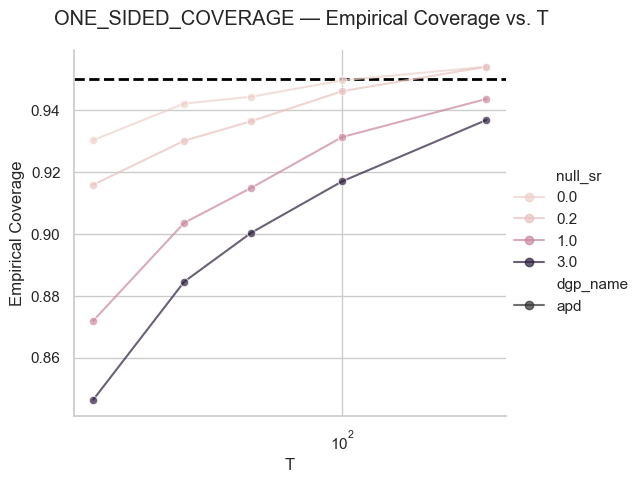

In [6]:
run_analysis(experiments, "aux", alpha=0.05)